# Descripcipción del proyecto

Film Junky Union, una nueva comunidad vanguardista para los aficionados de las películas clásicas, está desarrollando un sistema para filtrar y categorizar reseñas de películas. Tu objetivo es entrenar un modelo para detectar las críticas negativas de forma automática. Para lograrlo, utilizarás un conjunto de datos de reseñas de películas de IMDB con leyendas de polaridad para construir un modelo para clasificar las reseñas positivas y negativas. Este deberá alcanzar un valor F1 de al menos 0.85.

### Notas

- Para poder trabajar con este proyecto se tuvo que hacer de manera local para que este pudiese ejecutar de manera completa y fluida, ya que en la plataforma crasheaba al llegar a cierto punto.
- En la primera celda se instalan las librerias de maneara local para poder importarlas enseguida.
- Se instalan otros paquetes conforme se va necesitando de acuerdo al codigo.

## Inicialización

In [2]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Instalar todas las librerías listadas en la celda inicial (excluyendo módulos de la stdlib como math/warnings)
%pip install -q --upgrade spacy tqdm transformers torch scikit-learn pandas numpy seaborn matplotlib imbalanced-learn nltk wordcloud plotly lightgbm

# Verificar instalación imprimiendo versiones (manejo con try/except para evitar fallos)
packages = {
    'spacy': 'spacy',
    'tqdm': 'tqdm',
    'transformers': 'transformers',
    'torch': 'torch',
    'scikit-learn': 'sklearn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'seaborn': 'seaborn',
    'matplotlib': 'matplotlib',
    'imbalanced-learn': 'imblearn',
    'nltk': 'nltk',
    'wordcloud': 'wordcloud',
    'plotly': 'plotly',
    'lightgbm': 'lightgbm',
}

for pkg, mod_name in packages.items():
    try:
        mod = __import__(mod_name)
        ver = getattr(mod, '__version__', None)
        print(f'{pkg}: OK, version={ver}')
    except Exception as e:
        print(f'{pkg}: import failed: {e}')

Note: you may need to restart the kernel to use updated packages.
spacy: OK, version=3.8.11
tqdm: OK, version=4.67.3


C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: OK, version=5.2.0
torch: OK, version=2.10.0+cpu
scikit-learn: OK, version=1.8.0
pandas: OK, version=3.0.1
numpy: OK, version=2.4.2
seaborn: OK, version=0.13.2
matplotlib: OK, version=3.10.8
imbalanced-learn: OK, version=0.14.1
nltk: OK, version=3.9.2
wordcloud: OK, version=1.9.6
plotly: OK, version=6.5.2
lightgbm: OK, version=4.6.0


In [4]:
import math


import numpy as np

import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# la siguiente línea proporciona gráficos de mejor calidad en pantallas HiDPI
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8')

In [6]:
# esto es para usar progress_apply, puedes leer más en https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Cargar datos

In [38]:

df_reviews = pd.read_csv("C:\\Users\\rodri\\OneDrive\\Documentos\\PANCHO\\TripleTen\\Proyectos\\Sprint_17_Aprendizaje_Atomatico_Para_Textos\\imdb_reviews.tsv", sep='\t', dtype={'votes': 'Int64'})
print(df_reviews.info())

<class 'pandas.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  str    
 1   title_type       47331 non-null  str    
 2   primary_title    47331 non-null  str    
 3   original_title   47331 non-null  str    
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  str    
 6   runtime_minutes  47331 non-null  str    
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  str    
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  str    
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  str    
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  str    
 16  idx              47331 non-null  int64  
dtypes: Int64(1), float64(1)

In [19]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


## EDA

Veamos el número de películas y reseñas a lo largo de los años.

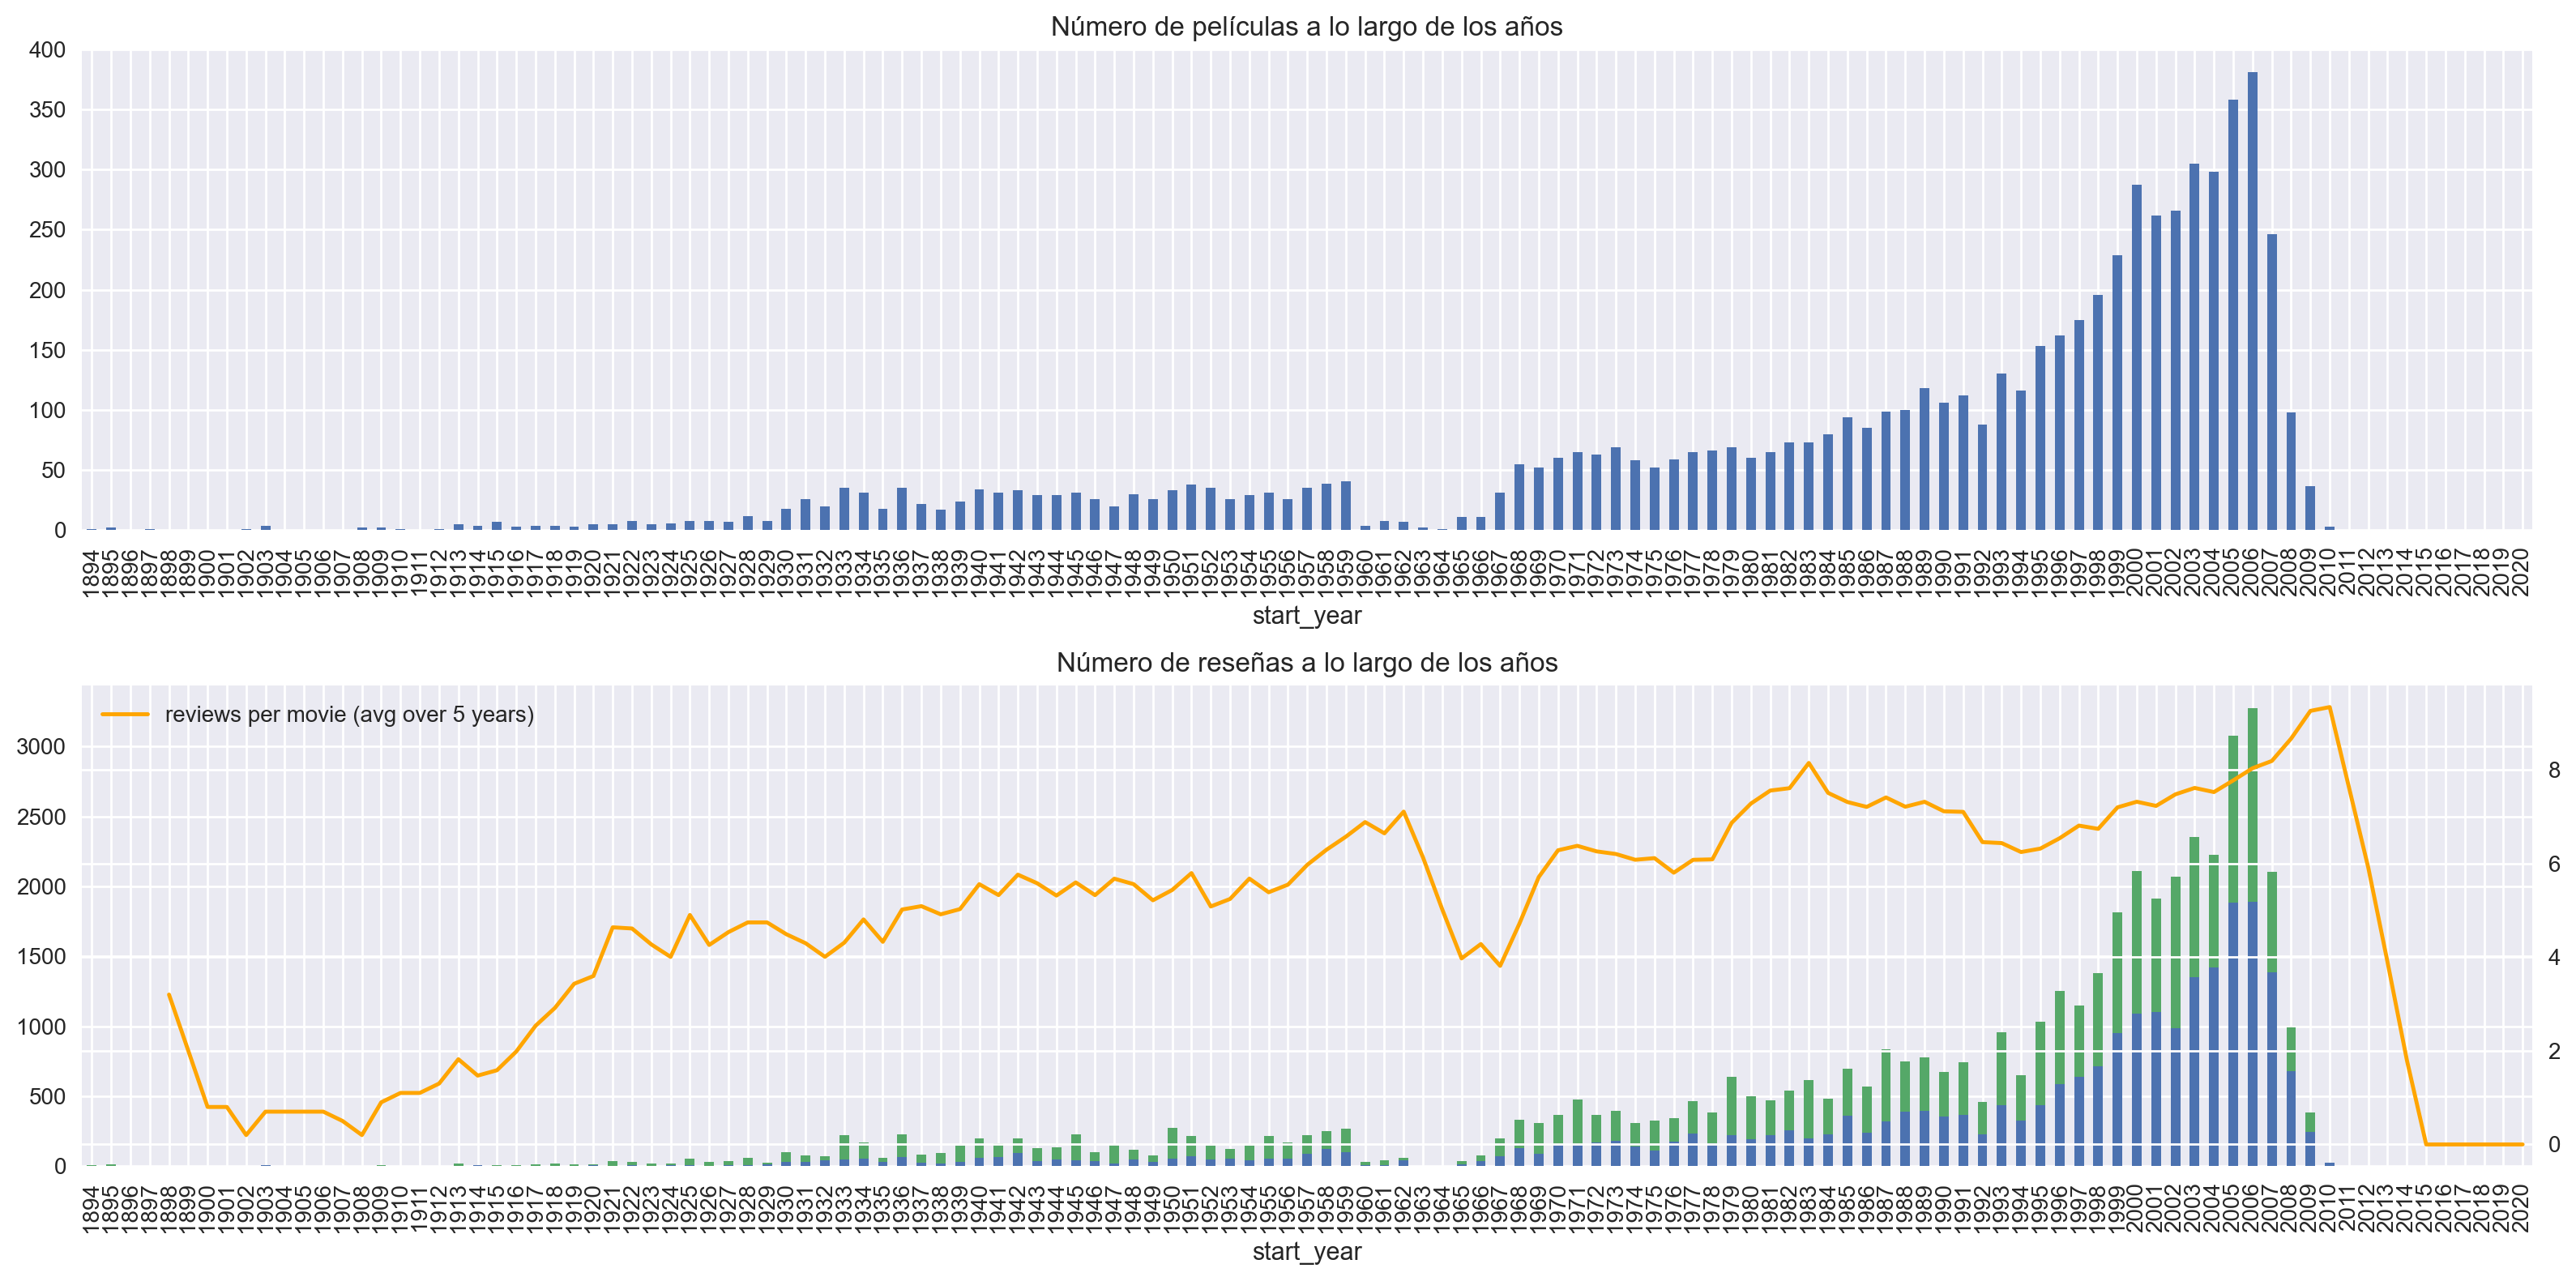

In [20]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de películas a lo largo de los años')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de reseñas a lo largo de los años')

fig.tight_layout()

Veamos la distribución del número de reseñas por película con el conteo exacto y KDE (solo para saber cómo puede diferir del conteo exacto)

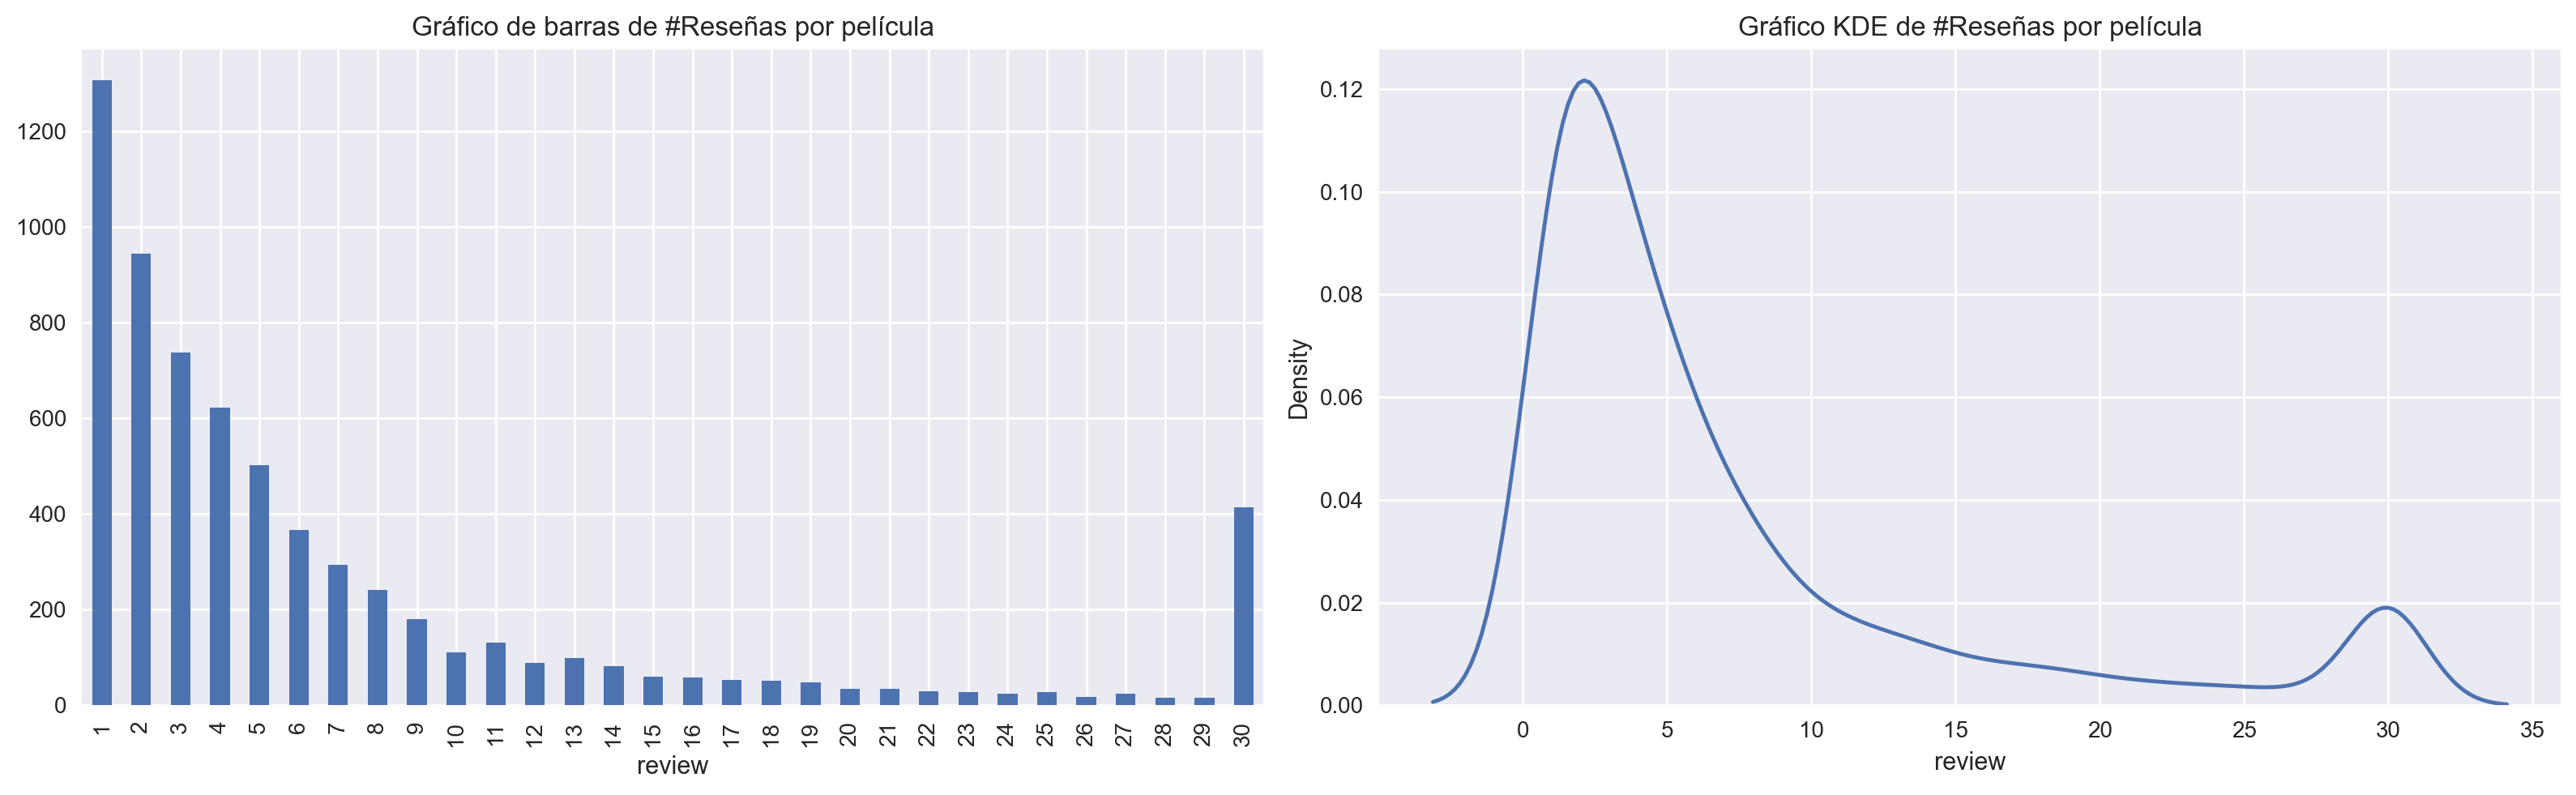

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de barras de #Reseñas por película')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico KDE de #Reseñas por película')

fig.tight_layout()

In [22]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

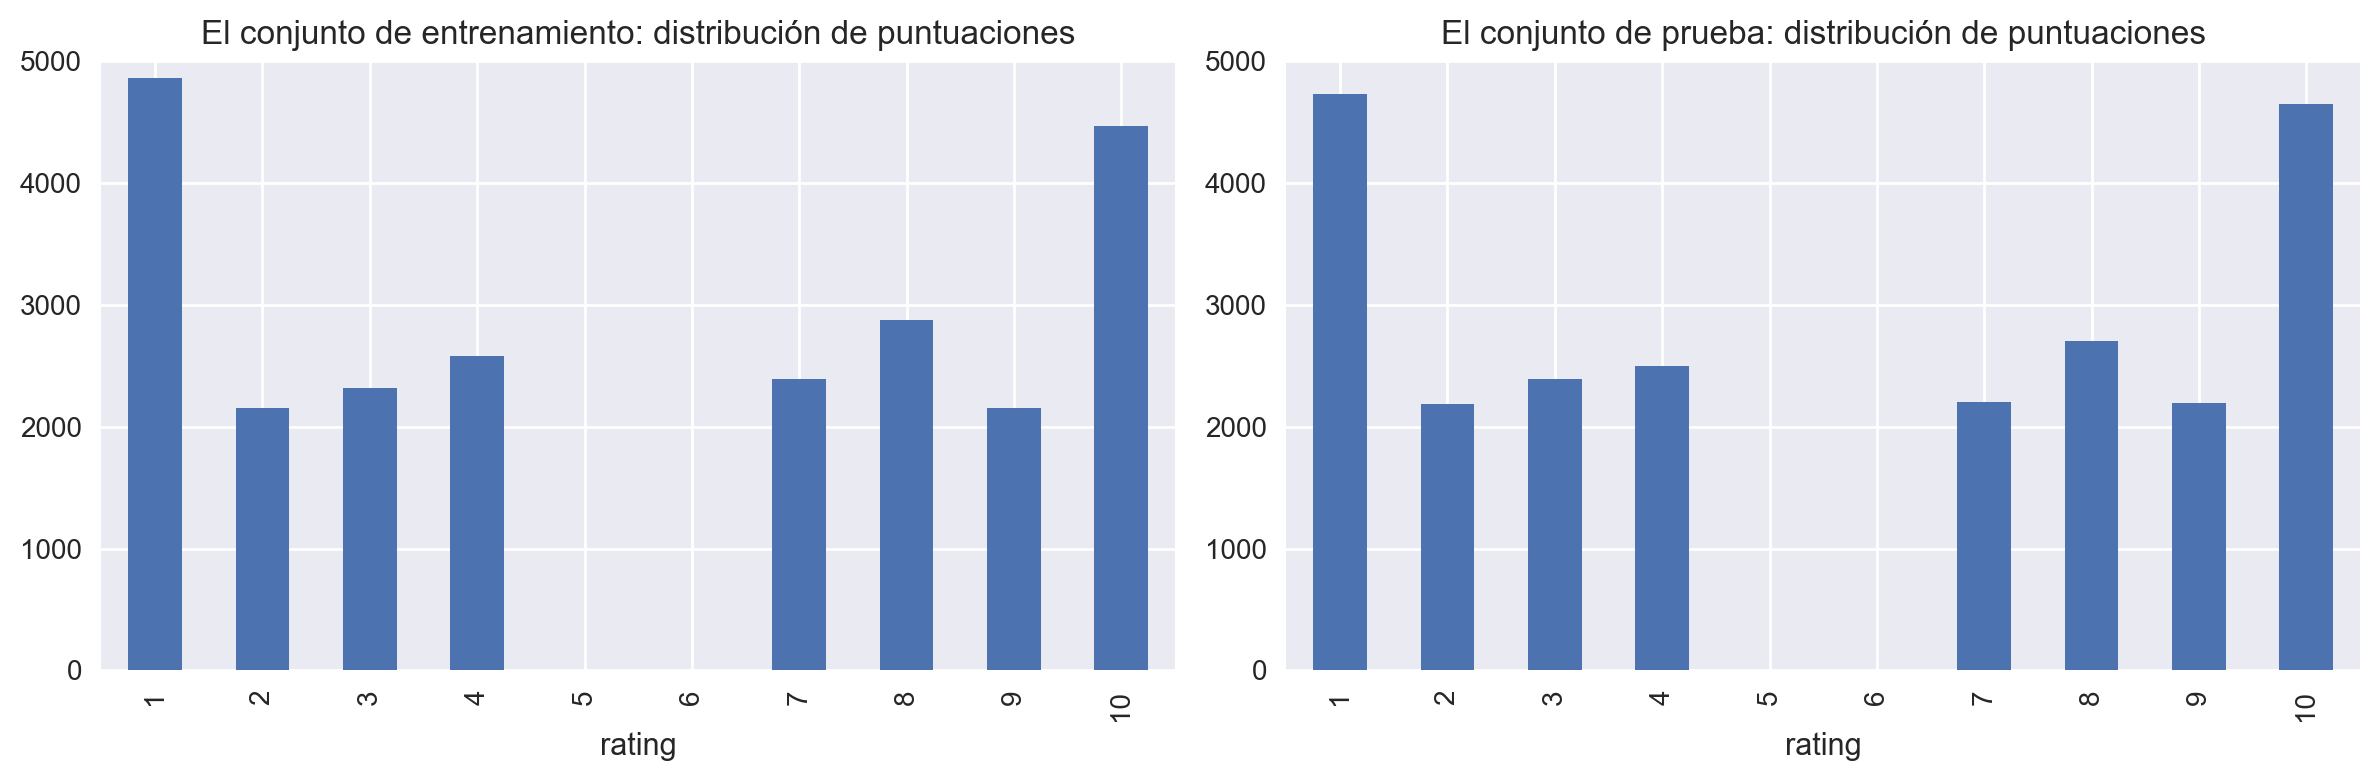

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de entrenamiento: distribución de puntuaciones')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de prueba: distribución de puntuaciones')

fig.tight_layout()

Distribución de reseñas negativas y positivas a lo largo de los años para dos partes del conjunto de datos

C:\Users\rodri\AppData\Local\Temp\ipykernel_70920\1324160450.py:14: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
C:\Users\rodri\AppData\Local\Temp\ipykernel_70920\1324160450.py:15: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
C:\Users\rodri\AppData\Local\Temp\ipykernel_70920\1324160450.py:30: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
C:\Users\rodri\AppData\Local\Temp\ipykernel_70920\1324160450.py:31: UserWarning: 

Support for a

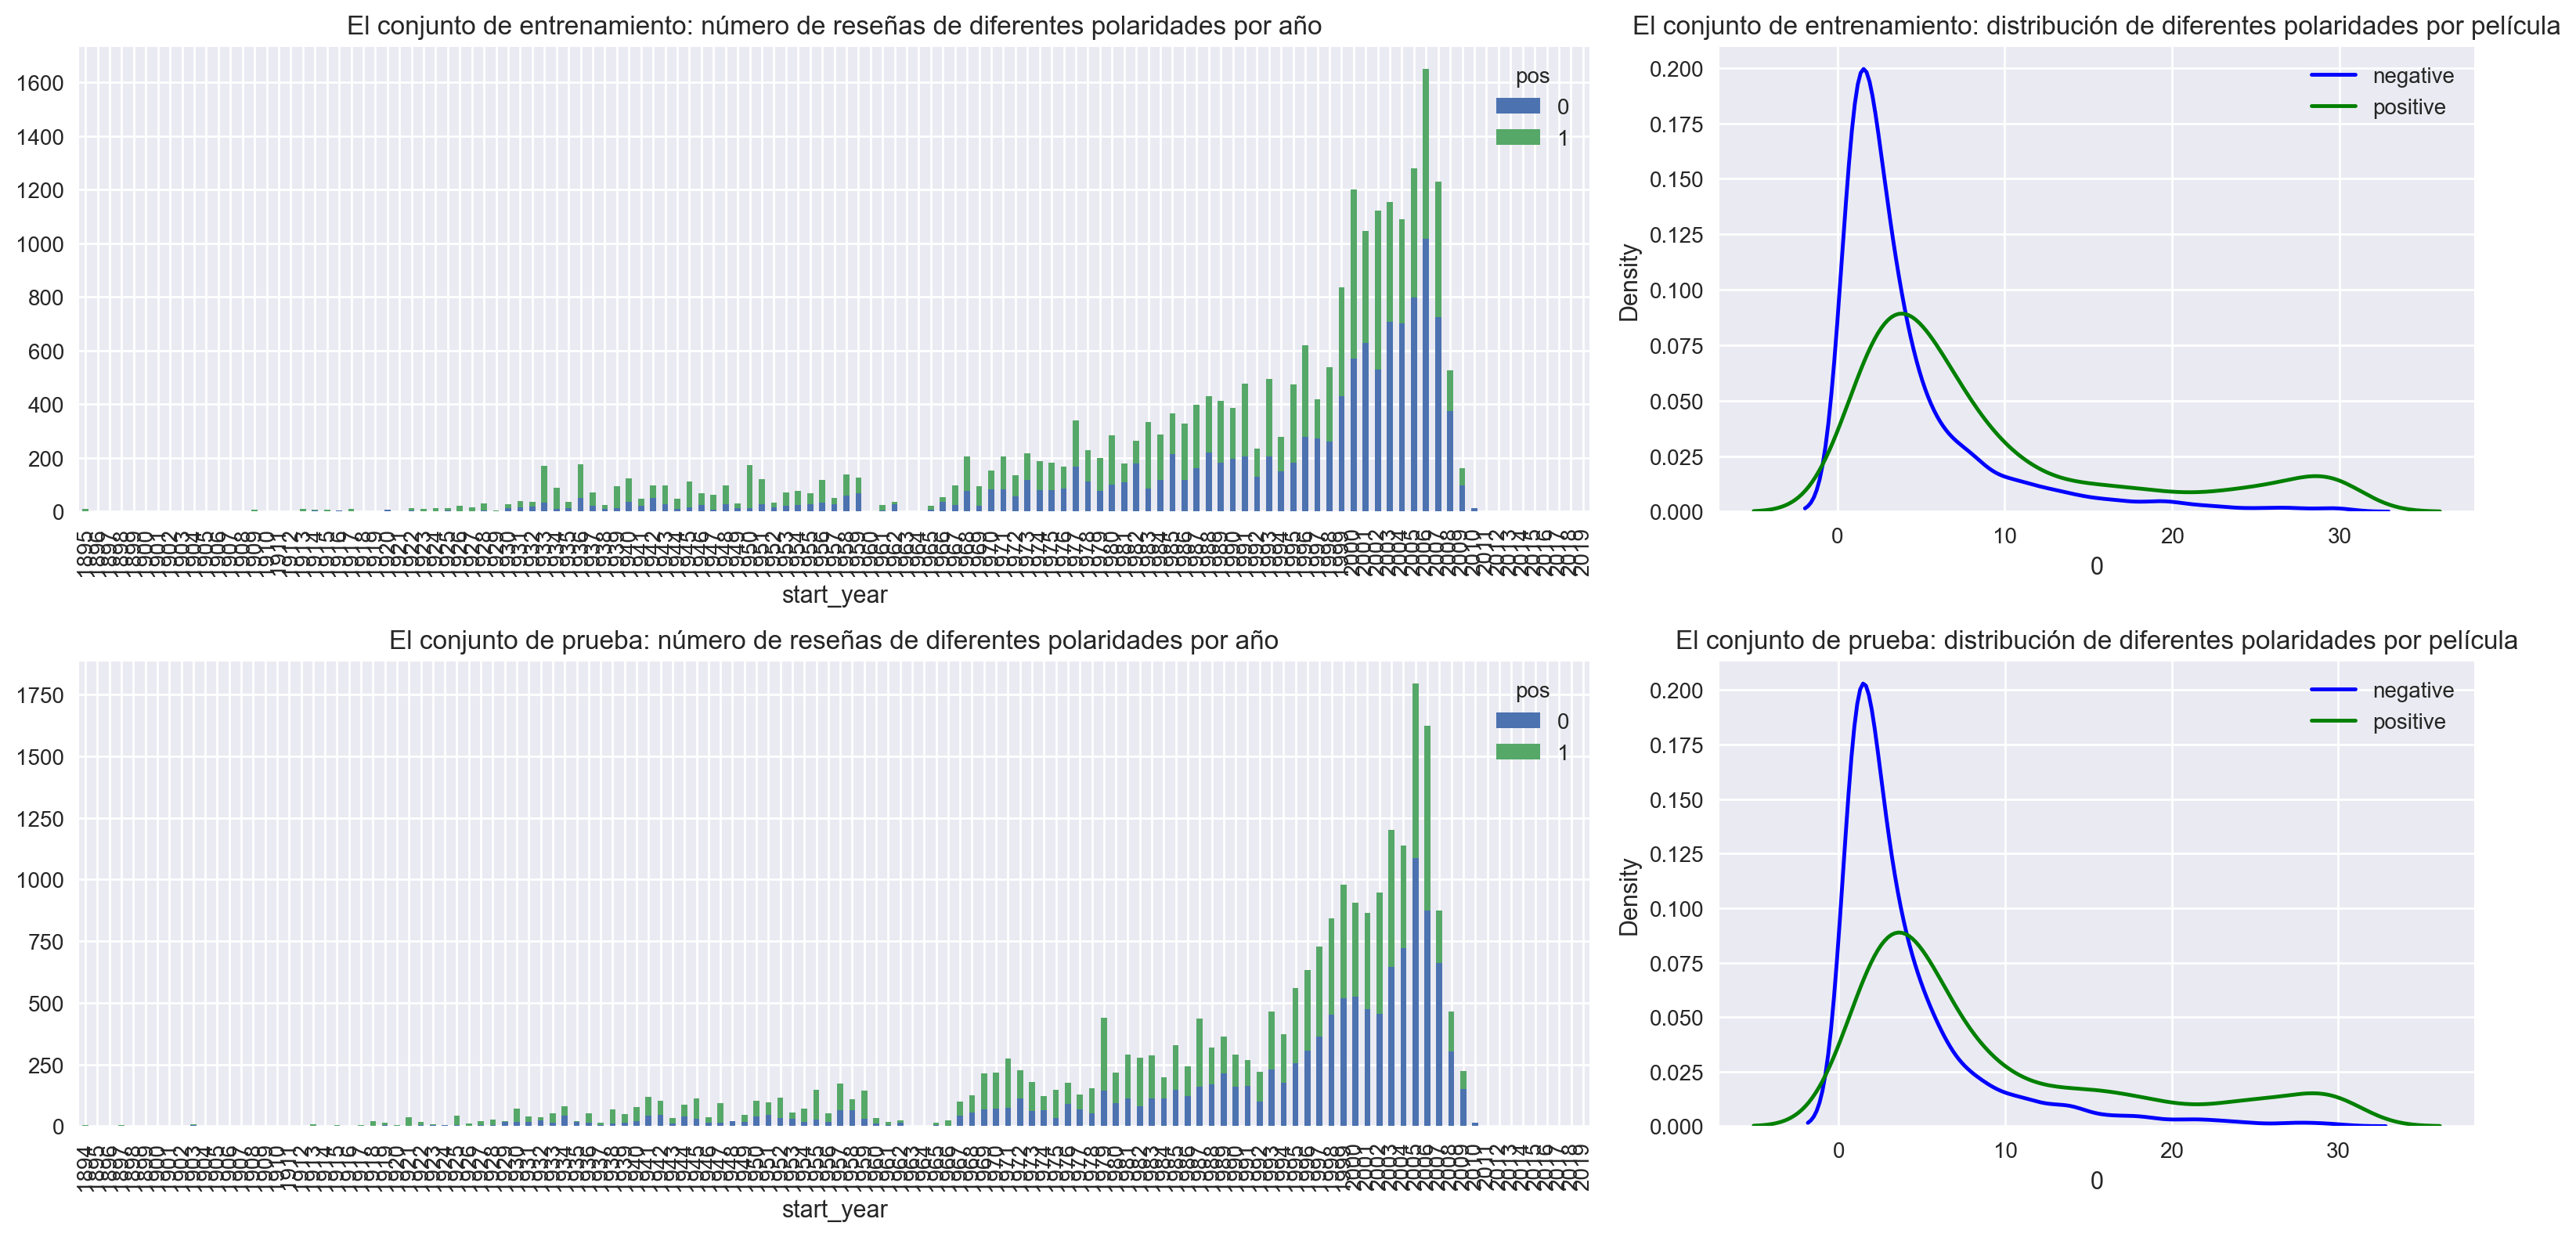

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de entrenamiento: número de reseñas de diferentes polaridades por año')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('El conjunto de entrenamiento: distribución de diferentes polaridades por película')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de prueba: número de reseñas de diferentes polaridades por año')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('El conjunto de prueba: distribución de diferentes polaridades por película')

fig.tight_layout()

## Procedimiento de evaluación

Composición de una rutina de evaluación que se pueda usar para todos los modelos en este proyecto

In [25]:
import sklearn.metrics as metrics
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[type] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps

        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1')

        # ROC
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'Curva ROC')

        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))

    print(df_eval_stats)

    return

In [26]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

def evaluate_model(model, X_train, y_train, X_test, y_test, target_names=('neg','pos')):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f'f1 macro: {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=target_names,digits=4))
    print('Matrix de Cobnfusion:\n', confusion_matrix(y_test, y_pred, labels=[0,1]))
    return f1

## Normalización

Suponemos que todos los modelos a continuación aceptan textos en minúsculas y sin dígitos, signos de puntuación, etc.

In [27]:
import re, html

TAG_RE = re.compile(r'<[^>]+>')
PUNCT_RE = re.compile(r'[^\w\s]')
DIGIT_RE = re.compile(r'\d+')

def normalize_text(s: str) -> str:
    if not isinstance(s,str):
        s = str(s)
    s = html.unescape(s)
    s = TAG_RE.sub(' ', s)
    s = s.lower()
    s = PUNCT_RE.sub(' ', s)
    s = DIGIT_RE.sub(' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s
    
df_reviews['review_norm'] = df_reviews['review'].astype(str).map(normalize_text) #Escribe aqui el codigo
df_reviews.head(2)

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx,review_norm
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335,the pakage implies that warren beatty and gold...
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336,how the hell did they get this made presenting...


## División entrenamiento / prueba

Por fortuna, todo el conjunto de datos ya está dividido en partes de entrenamiento/prueba; 'ds_part' es el indicador correspondiente.

In [28]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


In [29]:
df_reviews_train.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx,review_norm
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335,the pakage implies that warren beatty and gold...
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336,how the hell did they get this made presenting...
7,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,This true story of Carlson's Raiders is more o...,2,neg,0,train,9903,this true story of carlson s raiders is more o...
8,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,Should have been titled 'Balderdash!' Little i...,2,neg,0,train,9905,should have been titled balderdash little in t...
9,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,The movie 'Gung Ho!': The Story of Carlson's M...,4,neg,0,train,9904,the movie gung ho the story of carlson s makin...


## Trabajar con modelos

### Modelo 0 - Constante

In [30]:
from sklearn.dummy import DummyClassifier

In [31]:
# Creamos la columna de ceros para los features dummy de DummyClassifier

X_train_0 = np.zeros((len(df_reviews_train), 1))
X_test_0 = np.zeros((len(df_reviews_test), 1))

In [32]:
model_0 = DummyClassifier(strategy='most_frequent', random_state=42)

In [33]:
print("---Modelo 0 (Constante): Dummy (clase mas frecuente)---")
evaluate_model(model_0, X_train_0, train_target, X_test_0, test_target)

---Modelo 0 (Constante): Dummy (clase mas frecuente)---
f1 macro: 0.3340
              precision    recall  f1-score   support

         neg     0.5015    1.0000    0.6680     11803
         pos     0.0000    0.0000    0.0000     11732

    accuracy                         0.5015     23535
   macro avg     0.2508    0.5000    0.3340     23535
weighted avg     0.2515    0.5015    0.3350     23535

Matrix de Cobnfusion:
 [[11803     0]
 [11732     0]]


C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

0.3340030562001245

### Modelo 1 - NLTK, TF-IDF y LR

TF-IDF

In [34]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [35]:
# Vectorizador TF-IDF (palabras 1-2)

tf_idf_vectorizer_1 = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9, stop_words='english', strip_accents='unicode')
train_features_1 = tf_idf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tf_idf_vectorizer_1.transform(df_reviews_test['review_norm'])

In [36]:

# Modelo de Regrsion Logistica #1
# Unigrama y Bigrama

model_1 = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced', random_state=42)
print('---Modelo de Regresion Logistica #1 con TF-IDF word (1-2)---')
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)


---Modelo de Regresion Logistica #1 con TF-IDF word (1-2)---
f1 macro: 0.8783
              precision    recall  f1-score   support

         neg     0.8815    0.8750    0.8782     11803
         pos     0.8752    0.8816    0.8784     11732

    accuracy                         0.8783     23535
   macro avg     0.8783    0.8783    0.8783     23535
weighted avg     0.8783    0.8783    0.8783     23535

Matrix de Cobnfusion:
 [[10328  1475]
 [ 1389 10343]]


0.8783088522033018

### Modelo de Regresion Logistica de (3 a 5) TF-IDF

In [39]:
tf_idf_vectorizer_2 = TfidfVectorizer(analyzer='char', ngram_range=(3,5), min_df=2)
train_features_2 = tf_idf_vectorizer_2.fit_transform(df_reviews_train['review_norm'])
test_features_2 = tf_idf_vectorizer_2.transform(df_reviews_test['review_norm'])

In [40]:
# Modelo de Regrsion Logistica

model_2 = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced', random_state=42)

print('---Modelo de Regresion Logistica #2 con TF-IDF (char 3-5)---')
evaluate_model(model_2, train_features_2, train_target, test_features_2, test_target)

---Modelo de Regresion Logistica #2 con TF-IDF (char 3-5)---
f1 macro: 0.8847
              precision    recall  f1-score   support

         neg     0.8850    0.8852    0.8851     11803
         pos     0.8845    0.8842    0.8844     11732

    accuracy                         0.8847     23535
   macro avg     0.8847    0.8847    0.8847     23535
weighted avg     0.8847    0.8847    0.8847     23535

Matrix de Cobnfusion:
 [[10448  1355]
 [ 1358 10374]]


0.8847237381825274

### Modelo 3 - spaCy, TF-IDF y LR

In [41]:
try:
    import spacy
    try:
        nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])
    except Exception as e:
        print('No se pudo cargar "en_core_web_sm:"', e)
        mlp = None
except Exception as e:
    print('Spacy no disponible', e)
    nlp = None

No se pudo cargar "en_core_web_sm:" [E050] Can't find model 'en_core_web_sm'. It doesn't seem to be a Python package or a valid path to a data directory.


In [42]:
!python -m spacy download en_core_web_sm


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------------- -------------------------- 4.5/12.8 MB 20.7 MB/s eta 0:00:01
     --------------------------------- ----- 11.0/12.8 MB 26.5 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 25.9 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])

def text_preprocessing_3(text):
    t = text if isinstance(text, str) else str(text)

    if nlp is None:
        return t.lower()

    doc = nlp(t)

    tokens = [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    ]

    return " ".join(tokens)


In [57]:
# Vectorizador 3: TF-IDF 1 - 2 palabras sobre texto lematizado (si Spacy carga)

tf_idf_vectorizer_3 = TfidfVectorizer(ngram_range=(1,2),min_df=2, max_df=.9, stop_words='english', strip_accents='unicode')
train_features_3 = tf_idf_vectorizer_3.fit_transform(df_reviews_train['review_norm'].apply(text_preprocessing_3))
test_features_3 = tf_idf_vectorizer_3.transform(df_reviews_test['review_norm'].apply(text_preprocessing_3))


KeyboardInterrupt: 

In [ ]:
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner", "textcat"]  # solo necesitamos lematización
)


def preprocess_texts(texts, batch_size=3000):
    processed_texts = []

    # Generador que convierte todo a string por seguridad
    texts = (t if isinstance(t, str) else str(t) for t in texts)

    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=1):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.is_alpha and not token.is_stop
        ]
        processed_texts.append(" ".join(tokens))

    return processed_texts

In [59]:
train_lemmas = preprocess_texts(df_reviews_train["review_norm"])
test_lemmas = preprocess_texts(df_reviews_test["review_norm"])

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X_train = tfidf.fit_transform(train_lemmas)
X_test = tfidf.transform(test_lemmas)


In [61]:
model_3 = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced', random_state=42)

print('---Modelo de Regresion Logistica #3 con TF-IDF texto lematizado (1 - 2 palabras)---')
evaluate_model(model_3, X_train, train_target, X_test, test_target)

---Modelo de Regresion Logistica #3 con TF-IDF texto lematizado (1 - 2 palabras)---
f1 macro: 0.8752
              precision    recall  f1-score   support

         neg     0.8791    0.8710    0.8751     11803
         pos     0.8715    0.8795    0.8754     11732

    accuracy                         0.8752     23535
   macro avg     0.8753    0.8753    0.8752     23535
weighted avg     0.8753    0.8752    0.8752     23535

Matrix de Cobnfusion:
 [[10281  1522]
 [ 1414 10318]]


0.8752493198817503

In [64]:
from sklearn.naive_bayes import ComplementNB
# Modelo de Naive Bayes

tf_idf_vectorizer_4 = TfidfVectorizer(ngram_range=(1,2),min_df=2, max_df=.9, stop_words='english', strip_accents='unicode')
train_features_4 = tf_idf_vectorizer_4.fit_transform(df_reviews_train['review_norm'])
test_features_4 = tf_idf_vectorizer_4.transform(df_reviews_test['review_norm'])


In [65]:
model_4 = ComplementNB()

print('---Modelo Naive Bayes con TF-IDF (1 - 2 palabras)---')
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)

---Modelo Naive Bayes con TF-IDF (1 - 2 palabras)---
f1 macro: 0.8507
              precision    recall  f1-score   support

         neg     0.8281    0.8869    0.8565     11803
         pos     0.8775    0.8148    0.8450     11732

    accuracy                         0.8509     23535
   macro avg     0.8528    0.8508    0.8507     23535
weighted avg     0.8527    0.8509    0.8507     23535

Matrix de Cobnfusion:
 [[10468  1335]
 [ 2173  9559]]


0.8507227143769722

### Modelo 4 - spaCy, TF-IDF y LGBMClassifier

In [66]:
from lightgbm import LGBMClassifier

In [67]:

# import re, spacy
# import numpy as np
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

# # Configuracion
# TEXT_COL = 'review'
# SPACY_MODEL = 'en_core_web_sm'

# # Tokenizador y Lematizador con SpaCy
# try: 
#     nlp = spacy.load(SPACY_MODEL, disable=['parser', 'ner', 'textcat'])
# except OSError:
#     nlp = spacy.blank('en')

# def spacy_lemmas(text):
#     text = re.sub(r'\s+', ' ', str(text).lower().strip())
#     doc = nlp(text)
#     toks = []
#     for t in doc:
#         if t.is_space or t.is_punct or t.like_num or t.is_quote or t.is_stop:
#             continue
#         toks.append(t.lemma_ if t.lemma_ not in ('', '-PRON-') else t.text)
#     return toks

# #TF-IDF Independiente
# tfidf = TfidfVectorizer(tokenizer=spacy_lemmas, preprocessor=None, lowercase=False, ngram_range=(1,2), min_df=5, max_df=.8, sublinear_tf=True, max_features = 5000)

# X_train = tfidf.fit_transform(df_reviews_train[TEXT_COL])
# X_test = tfidf.transform(df_reviews_test[TEXT_COL])


In [68]:
# Modelo de LGBMClassifier


# lgbm_clf = LGBMClassifier(objective='binary', 
#                          class_weight='balanced',
#                          random_state=42,
#                          n_estimators=300,
#                          learning_rate=.08,
#                          num_leaves=40,
#                          min_child_samples=20,
#                          subsample=.85,
#                          colsample_bytree=.85,
#                          n_jobs=-1,
#                           verbose=-1
#                          )
# lgbm_clf.fit(X_train, target_train.astype(int))

# y_proba = lgbm_clf(X_test)[:,1]
# y_pred = (y_proba >= 0.50).astpye(int)

# print(f'F1 {f1_score(test_target, ye pred):4f} | Accuracy: {accuracy_score(test_target. y pred):4f} ')
# print('\nReporte\n', classification_report(test_target, y_pred, digits=4))
# print('Matriz de Confusion:', confusion_matrix(test_target, y_pred))


###  Modelo 9 - BERT

In [69]:
import torch
import transformers

In [70]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 796.45it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [71]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None):

    ids_list = []
    attention_mask_list = []

    # texto al id de relleno de tokens junto con sus máscaras de atención

    # <código para crear ids_list y attention_mask_list>
    encoded = tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_attention_mask=True,
        return_tensors=None)
    
    ids_list = encoded['input_ids']
    attention_mask_list = encoded['attention_mask']
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
   

    # obtener insertados en lotes

    embeddings = []

   

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size))):
        start = batch_size * i
        end = batch_size * (i + 1)
        ids_batch = torch.LongTensor(ids_list[start:end]).to(device)
        # <código para crear attention_mask_batch
        attention_mask_batch = torch.LongTensor(attention_mask_list[start:end]).to(device)
        
        with torch.no_grad():
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())

    return np.concatenate(embeddings)

In [72]:
import torch
torch.cuda.is_available()  # debe ser True

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# Se revisa que cuda este disponible

False
CPU


In [75]:
# ¡Atención! La ejecución de BERT para miles de textos puede llevar mucho tiempo en la CPU, al menos varias horas
train_features_9 = tfidf.fit_transform(df_reviews_train['review_norm'].apply(preprocess_texts))
test_features_9 = tfidf.transform(df_reviews_test['review_norm'].apply(preprocess_texts))

KeyboardInterrupt: 

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

(23796,)
(23796, 289788)
(23796,)


In [ ]:
# si ya obtuviste los insertados, te recomendamos guardarlos para tenerlos listos si
np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# y cargar...
with np.load('features_9.npz', allow_pickle=True) as data:
     train_features_9 = data['train_features_9']
     test_features_9 = data['test_features_9']

## Mis reseñas

In [ ]:
# Nuevas reseñas para probar el modelo

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

"""
my_reviews = pd.DataFrame([
    'Simplemente no me gustó, no es mi tipo de película.',
    'Bueno, estaba aburrido y me quedé dormido a media película.',
    'Estaba realmente fascinada con la película',
    'Hasta los actores parecían muy viejos y desinteresados, y les pagaron por estar en la película. Qué robo tan desalmado.',
    '¡No esperaba que el relanzamiento fuera tan bueno! Los escritores realmente se preocuparon por el material original',
    'La película tuvo sus altibajos, pero siento que, en general, es una película decente. Sí la volvería a ver',
    'Qué pésimo intento de comedia. Ni una sola broma tiene sentido, todos actúan de forma irritante y ruidosa, ¡ni siquiera a los niños les gustará esto!',
    'Fue muy valiente el lanzamiento en Netflix y realmente aprecio poder seguir viendo episodio tras episodio de este nuevo drama tan emocionante e inteligente.'
], columns=['review'])
"""

my_reviews['review_norm'] = my_reviews['review'].astype(str).map(normalize_text) # <escribe aquí la misma lógica de normalización que para el conjunto de datos principal>

my_reviews.head()

,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn t expect the reboot to be so good write...


### Modelo 2

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(tf_idf_vectorizer_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

model_2.fit(train_features_2, train_target)

# En este punto el modelo ya está entrenado y se pueden hacer predicciones en nuevas reseñas
# Usando el modelo 2 entrenado y el vectorizador 2

0.23:  i did not simply like it not my kind of movie
0.17:  well i was bored and felt asleep in the middle of the movie
0.73:  i was really fascinated with the movie
0.09:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.30:  i didn t expect the reboot to be so good writers really cared about the source material
0.63:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.07:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.78:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Modelo 3

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tf_idf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

# En este punto el modelo ya está entrenado y se pueden hacer predicciones en nuevas reseñas
# Usando el modelo 3 entrenado y el vectorizador 3


0.31:  i did not simply like it not my kind of movie
0.25:  well i was bored and felt asleep in the middle of the movie
0.59:  i was really fascinated with the movie
0.24:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.28:  i didn t expect the reboot to be so good writers really cared about the source material
0.42:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.17:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.88:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Modelo 4

In [ ]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tf_idf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tf_idf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

# En este punto el modelo ya está entrenado y se pueden hacer predicciones en nuevas reseñas
# Usando el modelo 4 entrenado y el vectorizador 4

0.33:  i did not simply like it not my kind of movie
0.24:  well i was bored and felt asleep in the middle of the movie
0.58:  i was really fascinated with the movie
0.34:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.36:  i didn t expect the reboot to be so good writers really cared about the source material
0.46:  the movie had its upsides and downsides but i feel like overall it s a decent flick i could see myse
0.21:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.65:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


## Conclusiones

- Los modelos lineales basados en TF–IDF funcionaron muy bien para este problema y lograron alcanzar el objetivo de F1 ≥ 0.85, lo que indica que esta representación es suficiente para capturar el sentimiento en las reseñas de IMDB.

- En particular, los enfoques con TF–IDF de caracteres (n-gramas 3–5) + Regresión Logística y TF–IDF de palabras (n-gramas 1–2) + Regresión Logística fueron los que mejor balancearon precisión y recall, convirtiéndose en las opciones más sólidas del proyecto.

- Complement Naive Bayes destacó por ser un modelo rápido y sencillo; aunque quedó ligeramente por debajo de la Regresión Logística en desempeño, sigue siendo una alternativa competitiva y eficiente en términos de costo computacional.

- Debido al ligero desequilibrio entre clases, el uso de class_weight='balanced' ayudó a mejorar el recall de la clase minoritaria sin afectar de forma importante el desempeño general del modelo.

# Lista de comprobación

- [x]  Abriste el notebook
- [x]  Cargaste y preprocesaste los datos de texto para su vectorización
- [x]  Transformaste los datos de texto en vectores
- [x]  Entrenaste y probaste los modelos
- [x]  Se alcanzó el umbral de la métrica
- [x]  Colocaste todas las celdas de código en el orden de su ejecución
- [x]  Puedes ejecutar sin errores todas las celdas de código
- [x]  Hay conclusiones